markdown_content = """# Regressão Linear Múltipla

A **Regressão Linear Múltipla** é a evolução natural da Regressão Linear Simples. Enquanto na simples você utiliza apenas uma causa para explicar um resultado, na múltipla você usa **várias causas ao mesmo tempo**, já que no mundo real os problemas raramente dependem de um fator só.

## A Explicação em 3 Pontos Simples

1. **O Objetivo:** Descobrir como *várias* variáveis diferentes (ex: Distância percorrida, Peso da carga e Intensidade da chuva) influenciam juntas o resultado final (ex: Tempo de entrega).
2. **O "Plano" (A Reta Evoluída):** Como agora temos múltiplas informações, o modelo deixa de ser uma simples linha bidimensional. O computador passa a desenhar um **"plano"** (uma superfície em 3D ou mais dimensões) que tenta se ajustar o mais perto possível de todos os dados cruzados.
3. **A Previsão:** Com esse modelo pronto, se você fornecer vários valores novos de uma vez (ex: *"Vou percorrer 20km, carregando 15kg, debaixo de chuva"*), a regressão avalia o peso de cada um desses fatores em conjunto e entrega o resultado esperado mais preciso (ex: *"Vai levar 75 minutos"*).

---

## A Equação Matemática

A fórmula básica é uma extensão direta da modelo simples:

$$Y = \\alpha + \\beta_1 X_1 + \\beta_2 X_2 + \\dots + \\beta_n X_n$$

* **$Y$**: O que você quer descobrir (ex: Tempo).
* **$X_1, X_2, \\dots, X_n$**: As várias informações independentes que você já tem (ex: Distância, Peso, Chuva, etc.).
* **$\\alpha$ (alfa)**: O ponto de partida (intercepto), ou seja, qual seria o valor de $Y$ se todos os $X$ fossem zero.
* **$\\beta_1, \\beta_2, \\dots, \\beta_n$ (betas)**: São os "pesos" numéricos (coeficientes) de cada variável. O modelo aprende qual informação impacta mais o resultado final (ex: a chuva pode atrasar mais a entrega do que o peso da carga).

---

## Em Resumo

É a combinação de várias informações diferentes em uma única equação matemática para prever o futuro com mais precisão, entendendo não apenas **o que** afeta o resultado, mas **qual fator é mais importante**.

### Exemplo: Estimando o Modelo: O Impacto da Idade e Horas no CPI

1 - Importação dos pacotes

In [1]:
import pandas as pd # manipulação de dados em formato de dataframe
import numpy as np # operações matemáticas
import seaborn as sns # visualização gráfica
import matplotlib.pyplot as plt # visualização gráfica
import plotly.graph_objects as go # gráficos 3D
from scipy.stats import pearsonr # correlações de Pearson
import statsmodels.api as sm # estimação de modelos
from statsmodels.iolib.summary2 import summary_col # comparação entre modelos
from sklearn.preprocessing import LabelEncoder # transformação de dados
import pingouin as pg # outro modo para obtenção de matrizes de correlações
from statstests.process import stepwise # procedimento Stepwise
from statstests.tests import shapiro_francia # teste de Shapiro-Francia
from scipy.stats import boxcox # transformação de Box-Cox
from scipy.stats import norm # para plotagem da curva normal
from scipy import stats # utilizado na definição da função 'breusch_pagan_test'

import warnings
warnings.filterwarnings('ignore')

2 - Carregando Dados

In [2]:
# CARREGAMENTO DA BASE DE DADOS
df_paises = pd.read_csv('paises.csv', delimiter=',', encoding="utf-8")
df_paises

,pais,cpi,idade,horas
0,Argentina,3.9,72,35.0
1,Australia,8.7,64,32.0
2,Austria,7.9,72,32.0
3,Belgium,7.1,67,30.1
4,Brazil,4.0,59,35.0
5,Canada,8.9,61,33.4
6,Chile,6.2,70,34.0
7,China,2.5,49,34.0
8,Colombia,4.0,79,33.0
9,Cyprus,6.3,58,32.0


2.1 - Caracteristicas das variaveis dotaset

In [3]:
# Características das variáveis do dataset
df_paises.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pais    50 non-null     str    
 1   cpi     50 non-null     float64
 2   idade   50 non-null     int64  
 3   horas   50 non-null     float64
dtypes: float64(2), int64(1), str(1)
memory usage: 1.7 KB


2.2 - Estatísticas univariadas

In [4]:
# Estatísticas univariadas
df_paises.describe()

,cpi,idade,horas
count,50.000000,50.000000,50.000000
mean,4.894000,60.480000,32.660000
std,2.678974,10.022913,2.431091
min,0.800000,34.000000,26.800000
25%,2.575000,58.000000,31.400000
50%,3.950000,62.000000,32.600000
75%,7.475000,66.750000,34.400000
max,9.300000,79.000000,38.100000


3 - Gráfico 3D com scatter gerado em HTML e aberto no browser(figura 'EXEMPLO2_scatter3D.html' salva na pasta do curso)

In [5]:
trace = go.Scatter3d(
    x=df_paises['horas'], 
    y=df_paises['idade'], 
    z=df_paises['cpi'], 
    mode='markers',
    marker={
        'size': 10,
        'color': 'darkorchid',
        'opacity': 0.7,
    },
)

layout = go.Layout(
    margin={'l': 0, 'r': 0, 'b': 0, 't': 0},
    width=800,
    height=800,
    plot_bgcolor='white',
    scene=dict(
        xaxis=dict(
            gridcolor='rgb(200, 200, 200)',
            backgroundcolor='whitesmoke'
        ),
        yaxis=dict(
            gridcolor='rgb(200, 200, 200)',
            backgroundcolor='whitesmoke'
        ),
        zaxis=dict(
            gridcolor='rgb(200, 200, 200)',
            backgroundcolor='whitesmoke'
        )
    )
)

data = [trace]

plot_figure = go.Figure(data=data, layout=layout)
plot_figure.update_layout(scene=dict(
    xaxis_title='horas',
    yaxis_title='idade',
    zaxis_title='cpi'
))

plot_figure.write_html('EXEMPLO2_scatter3D.html')

# Abre o arquivo HTML no browser
import webbrowser
webbrowser.open('EXEMPLO2_scatter3D.html')

True

4 - Correlação

4.1 - Matriz de correlações

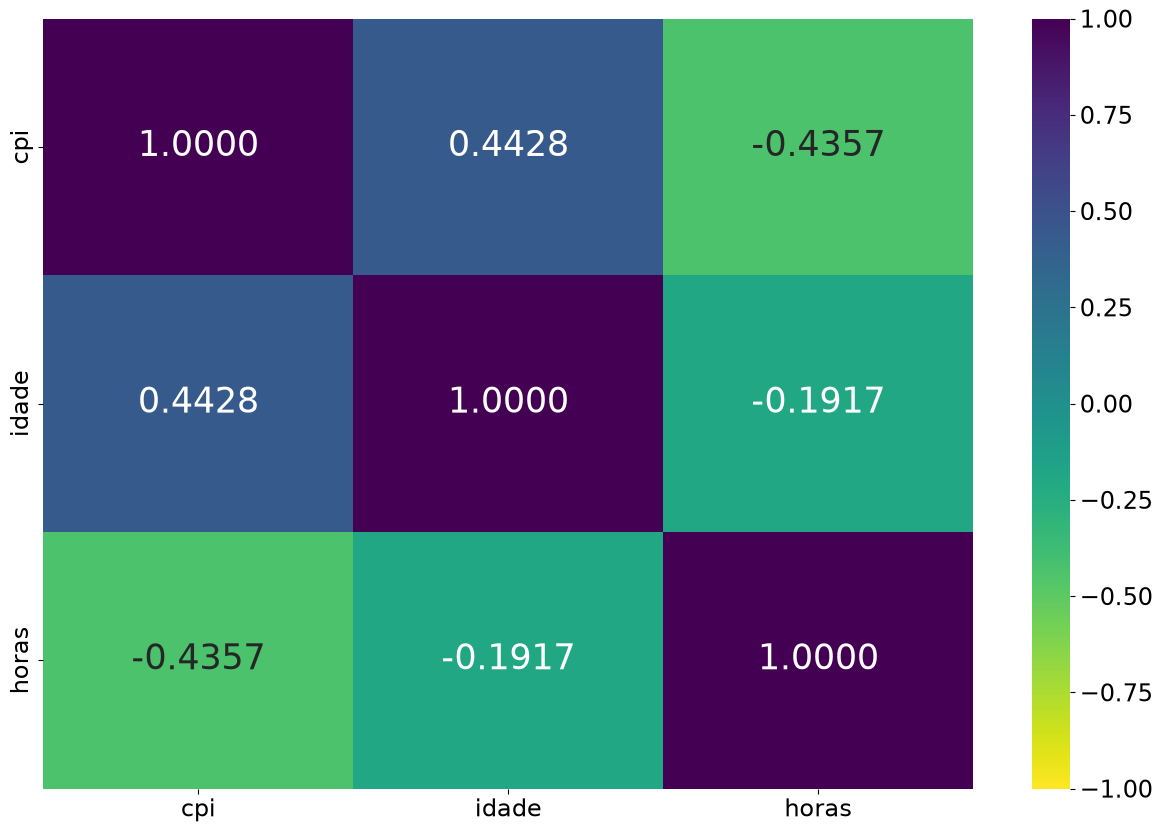

In [6]:
correlation_matrix = df_paises.iloc[:,1:4].corr()
correlation_matrix

# Mapa de calor com as correlações entre todas as variáveis quantitativas
plt.figure(figsize=(15, 10))
heatmap = sns.heatmap(correlation_matrix, annot=True, fmt=".4f",
                      cmap=plt.cm.viridis_r,
                      annot_kws={'size': 25}, vmin=-1, vmax=1)
heatmap.set_xticklabels(heatmap.get_xticklabels(), fontsize=17)
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontsize=17)
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=17)
plt.show()

# Paletas de cores ('_r' reverte a sequência de cores):
# viridis
# inferno
# magma
# cividis
# coolwarm
# Blues
# Greens
# Reds

4.2 - Diagrama interessante (grafo) que mostra a inter-relação entre as variáveis e a magnitude das correlações entre elas

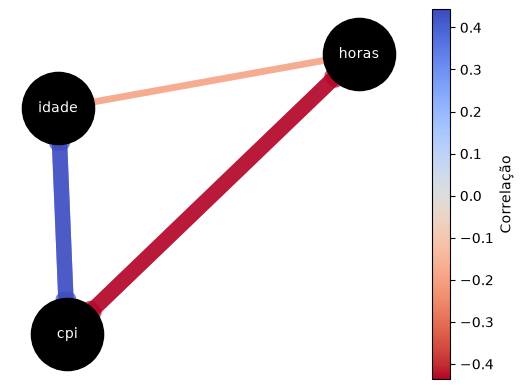

In [7]:
#variáveis e a magnitude das correlações entre elas

# conda install networkx
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Criação de um grafo direcionado
G = nx.DiGraph()

# Adição das variáveis como nós do grafo
for variable in correlation_matrix.columns:
    G.add_node(variable)

# Adição das arestas com espessuras proporcionais às correlações
for i, variable1 in enumerate(correlation_matrix.columns):
    for j, variable2 in enumerate(correlation_matrix.columns):
        if i != j:
            correlation = correlation_matrix.iloc[i, j]
            if abs(correlation) > 0:
                G.add_edge(variable1, variable2, weight=correlation)

# Obtenção da lista de correlações das arestas
correlations = [d["weight"] for _, _, d in G.edges(data=True)]

# Definição da dimensão dos nós
node_size = 2700

# Definição da cor dos nós
node_color = 'black'

# Definição da escala de cores das retas (correspondência com as correlações)
cmap = plt.colormaps.get_cmap('coolwarm_r')

# Criação de uma lista de espessuras das arestas proporcional às correlações
edge_widths = [abs(d["weight"]) * 25 for _, _, d in G.edges(data=True)]

# Criação do layout do grafo com maior distância entre os nós
pos = nx.spring_layout(G, k=0.75)  # k para controlar a distância entre os nós

# Desenho dos nós e das arestas com base nas correlações e espessuras
nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color=node_color)
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=correlations,
                       edge_cmap=cmap, alpha=0.7)

# Adição dos rótulos dos nós
labels = {node: node for node in G.nodes}
nx.draw_networkx_labels(G, pos, labels, font_size=10, font_color='white')

# Ajuste dos limites dos eixos
ax = plt.gca()
ax.margins(0.1)
plt.axis("off")

# Criação da legenda com a escala de cores definida
smp = cm.ScalarMappable(cmap=cmap)
smp.set_array([min(correlations), max(correlations)])
cbar = plt.colorbar(smp, ax=ax, label='Correlação')

# Exibição do gráfico
plt.show()

4.3 - Matriz de correlações mais elaborada, com uso da função 'rcorr' do pacote 'pingouin'

In [8]:
correlation_matrix2 = pg.rcorr(df_paises, method='pearson',
                               upper='pval', decimals=6,
                               pval_stars={0.01: '***',
                                           0.05: '**',
                                           0.10: '*'})
correlation_matrix2

,cpi,idade,horas
cpi,-,***,***
idade,0.442838,-,
horas,-0.435724,-0.191748,-


*** 99% de nivel de significancia

 ** 95% de nivel de significancia
 
  * 90% de nivel de significancia

5 - Gráfico com distribuições das variáveis, scatters, valores das correlações e respectivas significâncias estatísticas


<Figure size 2000x1000 with 0 Axes>

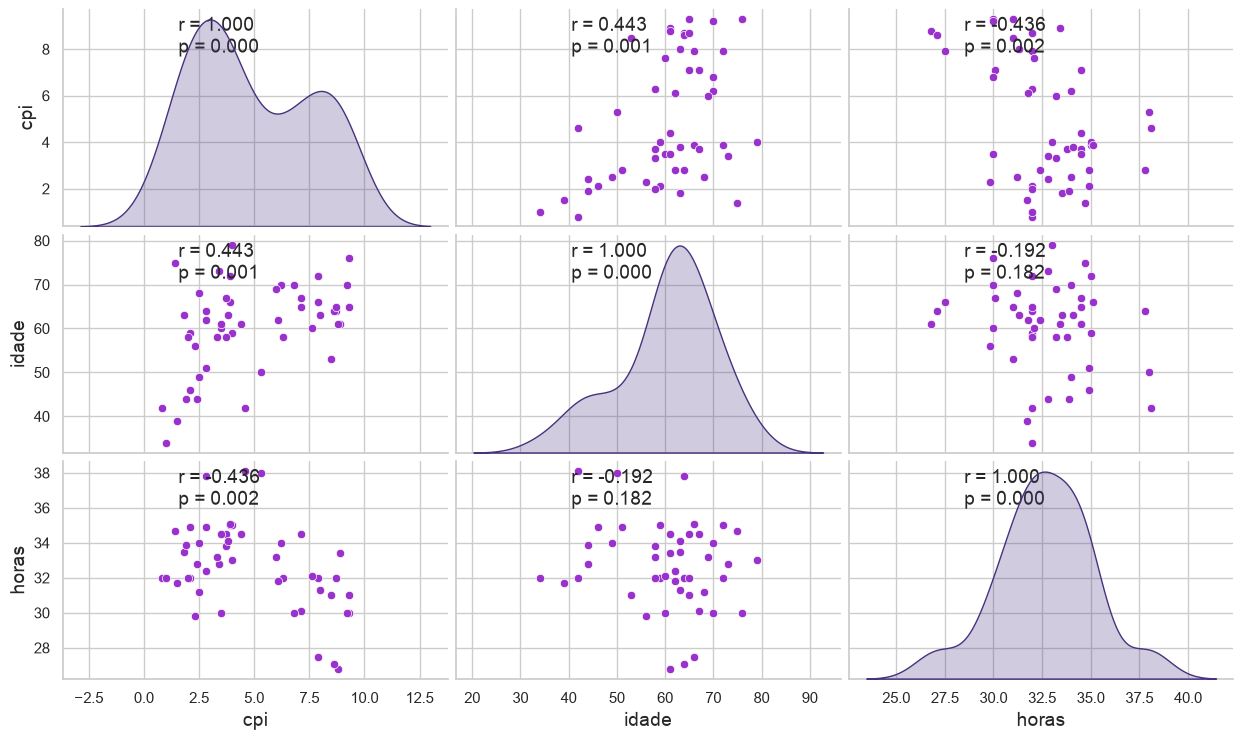

In [9]:
def corrfunc(x, y, **kws):
    (r, p) = pearsonr(x, y)
    ax = plt.gca()
    ax.annotate("r = {:.3f}".format(r),
                xy=(.30, .9), xycoords=ax.transAxes, fontsize=14)
    ax.annotate("p = {:.3f}".format(p),
                xy=(.30, .8), xycoords=ax.transAxes, fontsize=14)

# Configuração do gráfico
sns.set(style="whitegrid", palette="viridis")

plt.figure(figsize=(20,10))
graph = sns.pairplot(df_paises, diag_kind="kde",
                     plot_kws={"color": "darkorchid"},
                     height=2.5, aspect=1.7)
graph.map(corrfunc)
for ax in graph.axes.flat:
    ax.set_xlabel(ax.get_xlabel(), fontsize=14)
    ax.set_ylabel(ax.get_ylabel(), fontsize=14)
plt.show()


6 - EEstimação de um modelo de regressão múltipla com as variáveis do dataframe 'df_paises'

In [10]:
# Estimando o modelo de regressão múltipla por OLS
modelo_paises = sm.OLS.from_formula("cpi ~ idade + horas", df_paises).fit()

6.1 - Parâmetros do 'modelo_paises'

In [11]:
print(modelo_paises.summary())

                            OLS Regression Results                            
Dep. Variable:                    cpi   R-squared:                       0.324
Model:                            OLS   Adj. R-squared:                  0.295
Method:                 Least Squares   F-statistic:                     11.26
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           0.000101
Time:                        22:14:01   Log-Likelihood:                -109.93
No. Observations:                  50   AIC:                             225.9
Df Residuals:                      47   BIC:                             231.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     11.9719      5.165      2.318      0.0

# cpi = 11.9719	+ (0.0997 x idade) + (-0.4013 x horas)

## 1. A Equação Final (Os Coeficientes)
Olhe para a coluna **`coef`** na tabela do meio. É aqui que o modelo te entrega aquela equação matemática que conversamos antes:

$$CPI = 11.97 + (0.0997 \\times Idade) - (0.4013 \\times Horas)$$

**O que isso significa na prática?**
* **Intercept (11.97):** É o ponto de partida. Se um país tivesse "Idade zero" e "Horas zero" (o que não existe na prática, mas é a base matemática), o CPI seria 11.97.
* **idade (0.0997):** O valor é **positivo**. Isso significa que, em média, para cada 1 ano a mais na variável `idade`, o CPI do país **aumenta** em 0.0997 pontos (mantendo as horas constantes).
* **horas (-0.4013):** O valor é **negativo**. Isso significa que, em média, para cada 1 hora a mais de trabalho, o CPI do país **cai** em 0.4013 pontos.

---

## 2. Essas variáveis são realmente importantes? (O P-Valor)
Na ciência de dados, não basta ter um coeficiente; precisamos saber se ele não foi obra do acaso. Para isso, olhamos a coluna **`P>|t|`** (o famoso P-valor).

**A regra de ouro é:** Se for menor que 0.05, a variável é estatisticamente significante.
* **idade:** P-valor de **0.004** (Menor que 0.05). **Aprovada!** A idade realmente impacta o CPI.
* **horas:** P-valor de **0.005** (Menor que 0.05). **Aprovada!** As horas também têm um impacto real no CPI.

> **Resumo:** O modelo confirmou matematicamente que as duas variáveis que você escolheu são úteis para explicar o CPI.

---

## 3. O Modelo como um todo é bom? (O R-Quadrado)
Agora olhe lá no topo da tabela, para o **`R-squared: 0.324`**.

O R-Quadrado ($R^2$) é uma nota de 0 a 1 que diz o quanto o seu modelo consegue explicar a realidade.
* O seu valor é **0.324** (ou **32,4%**).
* **Interpretação:** A `idade` e as `horas` juntas conseguem explicar **32,4%** de tudo o que faz o CPI de um país subir ou descer.


7 - Salvando os fitted values na base de dados
Jogando todas essas previsões do modelo lá dentro.

In [12]:
df_paises['cpifit'] = modelo_paises.fittedvalues
df_paises

,pais,cpi,idade,horas,cpifit
0,Argentina,3.9,72,35.0,5.103394
1,Australia,8.7,64,32.0,5.509820
2,Austria,7.9,72,32.0,6.307405
3,Belgium,7.1,67,30.1,6.571454
4,Brazil,4.0,59,35.0,3.807319
5,Canada,8.9,61,33.4,4.648854
6,Chile,6.2,70,34.0,5.305335
7,China,2.5,49,34.0,3.211674
8,Colombia,4.0,79,33.0,6.603955
9,Cyprus,6.3,58,32.0,4.911631


## 1. Os Acertos: Onde o modelo foi preciso (Menores Resíduos)
Existem casos em que a combinação de **Idade** e **Horas trabalhadas** foi excelente para prever o CPI. O modelo chegou muito perto da realidade:

* **Brasil:** O CPI real é 4.0 e o modelo previu 3.80. Um erro (resíduo) de apenas 0.20!
* **Turquia:** Real de 4.4 contra um previsto de 4.20. Erro de 0.20.
* **África do Sul:** Real de 2.8 contra um previsto de 3.18. Erro de 0.38.

Nesses países, o perfil de horas e idade da população se encaixa muito bem na equação matemática que o modelo calculou.

---

## 2. Os Erros: Onde o modelo "falhou" (Maiores Resíduos)
Aqui vemos o impacto prático dos 67,6% de informações que faltam no seu modelo (já que o $R^2$ explicava apenas 32,4%). O modelo erra bastante em países onde outras forças socioeconômicas pesam muito mais do que apenas a idade e as horas:

* **Países Altamente Desenvolvidos (Subestimados):** Austrália (Real: 8.7 | Previsto: 5.50) e Nova Zelândia (Real: 9.3 | Previsto: 6.01). O modelo previu notas médias, mas na realidade eles têm índices altíssimos. Como o modelo só olha para idade/horas, ele não consegue capturar o peso do desenvolvimento institucional e da transparência desses locais.
* **Casos Críticos (Superestimados):** Nas Filipinas, o modelo previu um CPI razoável de 5.52, mas a realidade é de 1.4. O modelo foi "otimista" demais porque a matemática não sabe que existem outros problemas profundos afetando o país.
* **República Tcheca:** O CPI real é 4.6, mas o modelo jogou a previsão lá no chão, para apenas 0.86. Foi um dos maiores erros de cálculo da tabela.

---

## 3. A Grande Conclusão da Análise (O Diagnóstico)
A tabela comprova visualmente o que os testes estatísticos mostraram:

1. **A regra matemática funciona:** Lembra que o coeficiente das horas era negativo (-0.40)? A tabela reflete isso. Países com carga horária muito alta, como a Polônia (38 horas) e a África do Sul (37.8 horas), tiveram previsões de CPI (`cpifit`) puxadas para baixo (1.70 e 3.18, respectivamente).
2. **O modelo está Incompleto (Underfitting):** A distância enorme entre o `cpi` e o `cpifit` em vários países prova que o fenômeno estudado é complexo demais para apenas duas variáveis.

> **Próximos passos em um projeto real:** Se você fosse continuar esse projeto, a análise indicaria que a próxima etapa não é mexer no código, mas sim voltar à fase de coleta de dados. Adicionar variáveis como PIB per capita (GDP), Nível de Escolaridade ou Índice de Democracia daria ao modelo as peças que faltam para entender o que realmente separa os países no topo e na base da tabela.

8 - Gráfico 3D com scatter e fitted values (superfície espacial) resultantes do 'modelo_paises', gerado em HTML e aberto no browser (figura 'EXEMPLO2_scatter3D_fitted.html' salva na pasta do curso)

In [13]:


# Dados observados ('scatter')
scatter = go.Scatter3d(
    x=df_paises['horas'],
    y=df_paises['idade'],
    z=df_paises['cpi'],
    mode='markers',
    marker=dict(
        size=10,
        color='darkorchid',
        opacity=0.7
    ),
    name='Observado'
)

# Ajuste do modelo
X = np.column_stack([
    np.ones(len(df_paises)),
    df_paises['horas'],
    df_paises['idade']
])

y = df_paises['cpi'].values

b0, b1, b2 = np.linalg.lstsq(X, y, rcond=None)[0]

# Definição da grade ('meshgrid')
horas_grid = np.linspace(df_paises['horas'].min(),
                          df_paises['horas'].max(), 50)

idade_grid = np.linspace(df_paises['idade'].min(),
                          df_paises['idade'].max(), 50)

H, I = np.meshgrid(horas_grid, idade_grid)

# Definição da superfície ('go.Surface')
Z = b0 + b1 * H + b2 * I

surface = go.Surface(
    x=horas_grid,
    y=idade_grid,
    z=Z,
    colorscale='Oranges',
    opacity=0.6,
    showscale=False,
    name='Superfície ajustada'
)

# Figura final
fig = go.Figure(data=[scatter, surface])

fig.update_layout(
    width=800,
    height=800,
    margin=dict(l=0, r=0, b=0, t=0),
    plot_bgcolor='white',
    scene=dict(
        xaxis=dict(
            title='horas',
            gridcolor='rgb(200,200,200)',
            backgroundcolor='whitesmoke'
        ),
        yaxis=dict(
            title='idade',
            gridcolor='rgb(200,200,200)',
            backgroundcolor='whitesmoke'
        ),
        zaxis=dict(
            title='cpi',
            gridcolor='rgb(200,200,200)',
            backgroundcolor='whitesmoke'
        )
    )
)

# Abre o arquivo HTML no browser
import webbrowser
fig.write_html('EXEMPLO2_scatter3D_fitted.html')
webbrowser.open('EXEMPLO2_scatter3D_fitted.html')


True

## RESUMO 

O exemplo foca em prever o **CPI (Índice de Percepção de Corrupção)** de 50 países usando duas variáveis principais: **idade média da população** e **horas trabalhadas**.

---

## 1. Os resultados são satisfatórios?
**Parcialmente.** Depende do seu objetivo e do que você chama de satisfatório:

* **Do ponto de vista estatístico (Sim):** As variáveis escolhidas (idade e horas) são estatisticamente significantes (P-valor < 0,05). Isso prova que elas realmente têm relação com a corrupção.
* **Do ponto de vista de precisão (Não muito):** O modelo tem um $R^2$ de 0,324 (32,4%). Isso significa que ele explica apenas 1/3 do que faz um país ser corrupto ou não. Os outros 67,6% dependem de fatores que não estão incluídos no modelo atual.

---

## 2. O modelo atende ou não?
Ele atende como um **estudo inicial e exercício didático**, mas não atende para fazer previsões precisas no mundo real.

* **Por que atende:** Ele confirma a teoria econômica/social. Por exemplo, o coeficiente das horas é negativo (-0,40), o que mostra que, estatisticamente, países com jornadas de trabalho exaustivas tendem a ter índices de percepção de corrupção piores (CPI mais baixo).
* **Por que NÃO atende:** Ele sofre de *Underfitting* (é um modelo simples demais). O erro (resíduo) é muito alto em países como Austrália, Nova Zelândia e Filipinas. O modelo tentou simplificar demais um problema que é estrutural, social, político e econômico usando apenas "idade" e "horas".

---

## 3. Quais seriam os próximos passos?
O caminho não seria mudar a matemática básica, mas sim **enriquecer os dados**:

1. **Adicionar Variáveis de Controle:** O CPI é influenciado por fatores muito mais fortes. Você deveria incluir:
   * **PIB per capita:** Países mais ricos geralmente têm instituições mais fortes e fiscalização melhor.
   * **Escolaridade:** Nível de educação e acesso à informação da população.
   * **Índice de Democracia:** Liberdade de imprensa e força/independência das instituições.
2. **Verificar Multicolinearidade:** O notebook menciona que o *Condition Number* é alto (1.13e+03), o que sugere que as variáveis podem estar altamente correlacionadas, "atrapalhando" uma a outra. Seria preciso investigar e tratar isso.
3. **Análise de Outliers:** Países como a República Tcheca tiveram erros de previsão bizarros na comparação com o valor real. Seria importante entender se esses dados são pontos fora da curva (outliers) que estão puxando a média e prejudicando o ajuste do modelo.
4. **Testar Modelos Não-Lineares:** Talvez a relação entre essas variáveis socioeconômicas não seja uma linha reta perfeita, mas algo que exija uma transformação matemática (como aplicar o logaritmo nas variáveis).
